In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load and merge datasets (same as BPN)
ppg = pd.read_csv('data_nba/Player Per Game.csv')
allstar = pd.read_csv('data_nba/All-Star Selections.csv')

ppg = ppg[ppg['lg'] == 'NBA'].copy()
allstar = allstar[allstar['lg'] == 'NBA'][['player_id', 'season']].drop_duplicates()
allstar['all_star'] = 1

df = ppg.merge(allstar, on=['player_id', 'season'], how='left')
df['all_star'] = df['all_star'].fillna(0).astype(int)

features = [
    'pts_per_game', 'trb_per_game', 'ast_per_game',
    'stl_per_game', 'blk_per_game', 'mp_per_game',
    'fg_percent', 'ft_percent', 'g', 'gs'
]
target = 'all_star'

df = df[['player', target] + features].reset_index(drop=True)

imputer = SimpleImputer(strategy='median')
df[features] = imputer.fit_transform(df[features])

X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'All-Stars in test: {y_test.sum()}')

Train: (24895, 10) | Test: (6224, 10)
All-Stars in test: 384


In [3]:
# Test different depths
depths = [3, 5, 10, 15, None]
results_depth = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    results_depth.append({'Max Depth': str(d), 'Accuracy (%)': round(acc * 100, 2)})
    print(f'Depth {str(d):5} → Accuracy: {acc:.4f}')

df_depth = pd.DataFrame(results_depth)
print('\n', df_depth)

Depth 3     → Accuracy: 0.9555
Depth 5     → Accuracy: 0.9592
Depth 10    → Accuracy: 0.9581
Depth 15    → Accuracy: 0.9537
Depth None  → Accuracy: 0.9507

   Max Depth  Accuracy (%)
0         3         95.55
1         5         95.92
2        10         95.81
3        15         95.37
4      None         95.07


In [7]:
# Best model + Classification Report
best_dt = DecisionTreeClassifier(max_depth=10, random_state=42)
best_dt.fit(X_train, y_train)
y_pred = best_dt.predict(X_test)

print("Classification Report ")
print(classification_report(y_test, y_pred, target_names=['Non All-Star', 'All-Star']))

# Recalling
sample = X_test[0].reshape(1, -1)
pred = best_dt.predict(sample)[0]
actual = y_test[0]
print(f'Recalling example → Predicted: {"All-Star" if pred == 1 else "Non All-Star"}')
print(f'Actual:              {"All-Star" if actual == 1 else "Non All-Star"}')

Classification Report 
              precision    recall  f1-score   support

Non All-Star       0.97      0.98      0.98      5840
    All-Star       0.69      0.58      0.63       384

    accuracy                           0.96      6224
   macro avg       0.83      0.78      0.80      6224
weighted avg       0.96      0.96      0.96      6224

Recalling example → Predicted: Non All-Star
Actual:              Non All-Star


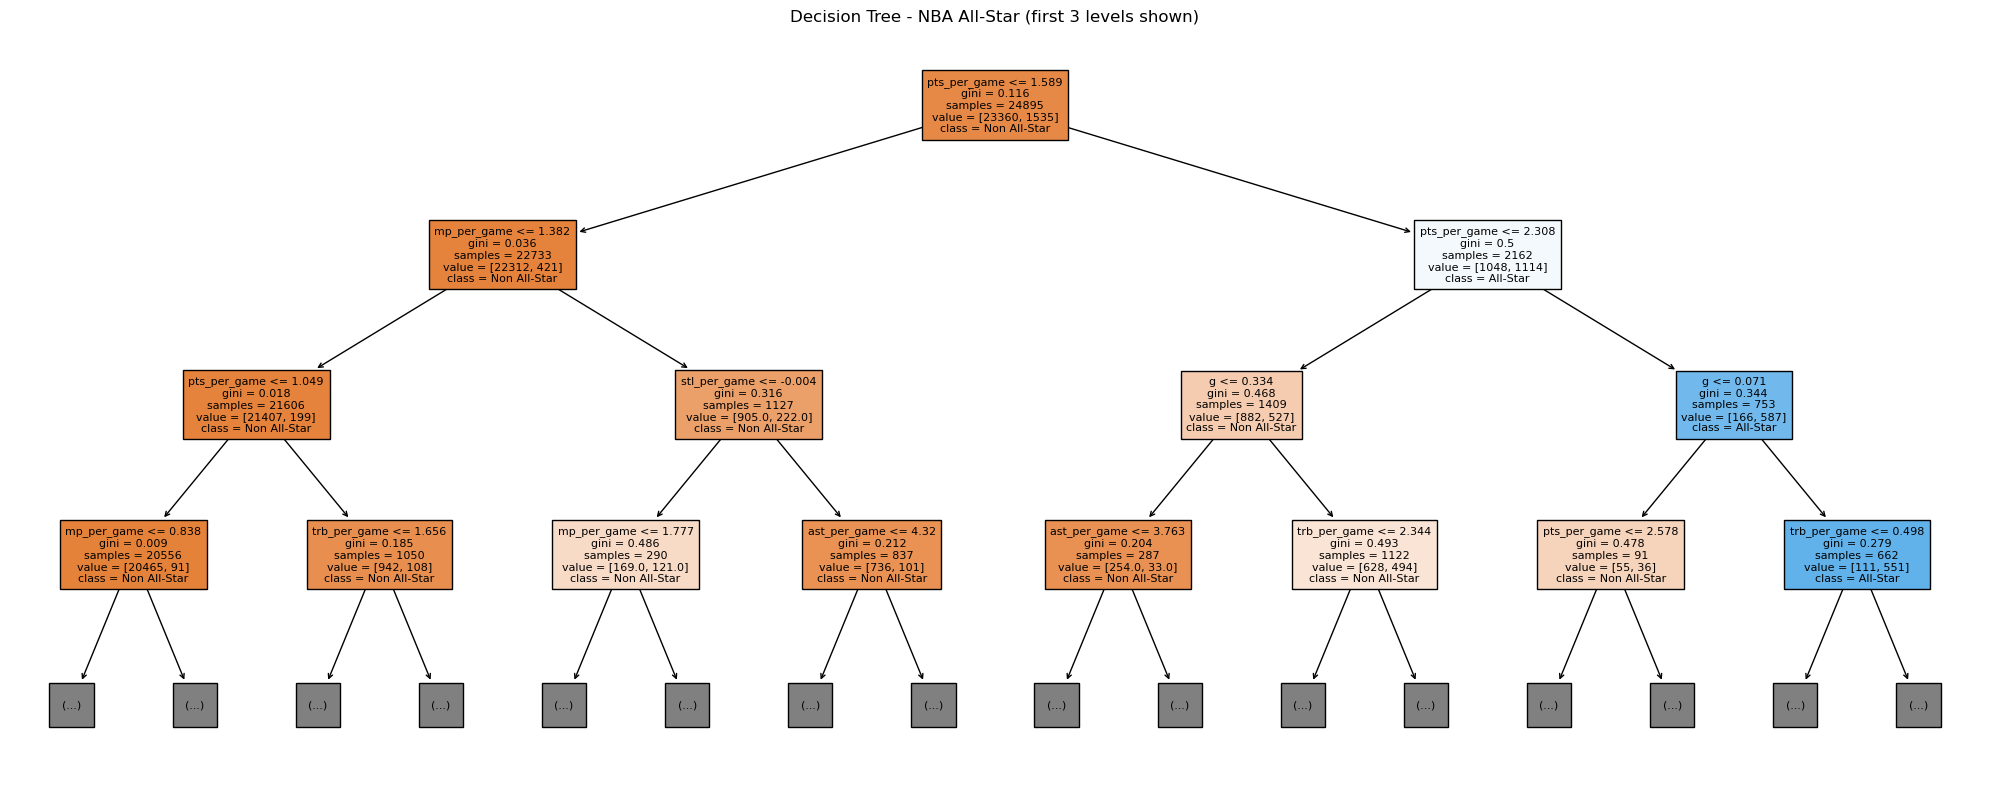

In [5]:
# Visualize the tree
plt.figure(figsize=(20, 8))
plot_tree(best_dt, feature_names=features,
          class_names=['Non All-Star', 'All-Star'],
          filled=True, max_depth=3, fontsize=8)
plt.title('Decision Tree - NBA All-Star (first 3 levels shown)')
plt.tight_layout()
plt.show()

                      Model  Accuracy (%)
0             BPN (LR=0.05)         96.45
1  Decision Tree (depth=10)         95.81


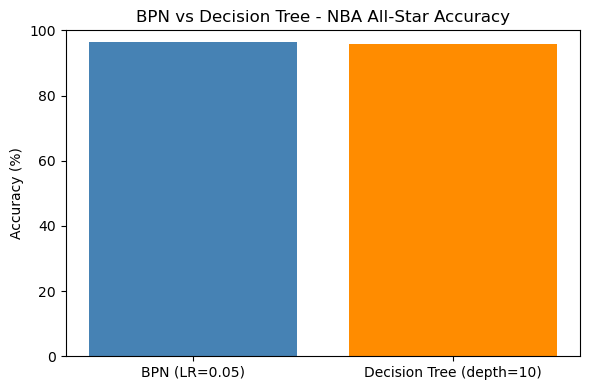

In [6]:
# BPN vs Decision Tree comparison
bpn_acc = 0.9645  # Best BPN: LR 0.05
dt_acc = accuracy_score(y_test, y_pred)

comparison = pd.DataFrame({
    'Model': ['BPN (LR=0.05)', 'Decision Tree (depth=10)'],
    'Accuracy (%)': [round(bpn_acc * 100, 2), round(dt_acc * 100, 2)]
})
print(comparison)

plt.figure(figsize=(6, 4))
plt.bar(comparison['Model'], comparison['Accuracy (%)'], color=['steelblue', 'darkorange'])
plt.title('BPN vs Decision Tree - NBA All-Star Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()